In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
%matplotlib inline

In [5]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

In [6]:
from sklearn.ensemble import RandomForestRegressor

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
import numpy as np

In [9]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/4. Scaling/Scaling(Frequency).csv")

In [10]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Publisher Freq,Developer Freq,Console Freq,Genre Freq,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,0.088207,0.047945,0.562657,1.000000,2010,0.313330,0.484506,0.048697,0.153468,0,High,2
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,0.088207,0.047945,0.378864,1.000000,2010,0.312532,0.500774,0.030944,0.155750,0,High,2
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,0.088207,0.047945,0.887218,1.000000,2000,0.520743,0.339938,0.029102,0.110217,0,High,2
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,0.088207,0.047945,0.543442,1.000000,2010,0.570888,0.335854,0.003781,0.089477,0,High,2
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,1.000000,0.125571,0.378864,0.522903,2010,0.409543,0.400928,0.027170,0.161696,1,High,2


In [11]:
df.dtypes # check data types

Game Title               object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
EU Sales                float64
Other Sales             float64
Release Year              int64
Publisher Freq          float64
Developer Freq          float64
Console Freq            float64
Genre Freq              float64
Decade                    int64
NA Share                float64
EU Share                float64
JP Share                float64
Other Share             float64
Is Recent                 int64
Game Quality             object
Game Quality Encoded      int64
dtype: object

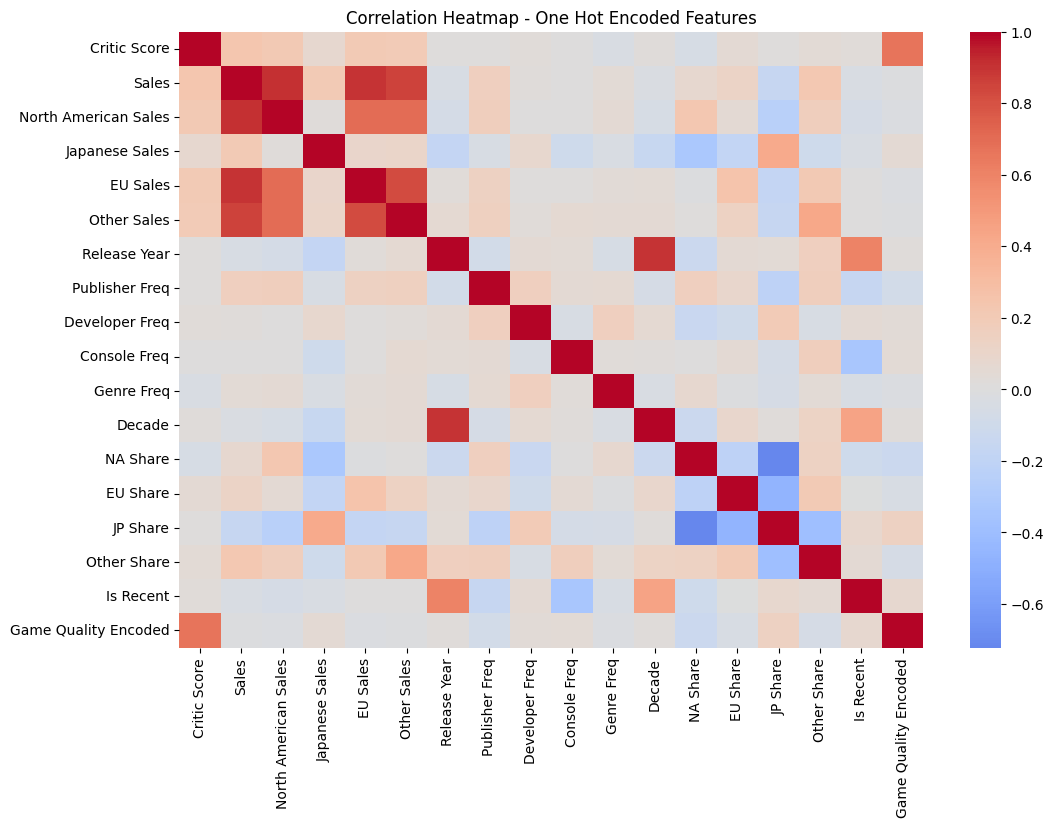

In [12]:
# Correlation Heatmap (EDA step)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - One Hot Encoded Features")
plt.show()

In [13]:
# Variance Threshold

X = df.drop(columns=["Sales"]).select_dtypes(include="number").copy()
y = df["Sales"].astype(float)

# make it finite + numeric
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

vt = VarianceThreshold(threshold=0.001)
X_vt = X.loc[:, vt.fit(X).get_support()]

print("Original features:", X.shape[1])
print("After VarianceThreshold:", X_vt.shape[1])

Original features: 17
After VarianceThreshold: 17


Top MI features:
 Other Share             1.902606
NA Share                1.540930
EU Share                1.389150
North American Sales    1.144163
Other Sales             0.740929
EU Sales                0.701821
Japanese Sales          0.580207
JP Share                0.297262
Publisher Freq          0.145774
Console Freq            0.102324
Developer Freq          0.082756
Critic Score            0.073492
Genre Freq              0.055332
Release Year            0.046289
Decade                  0.028191
dtype: float64


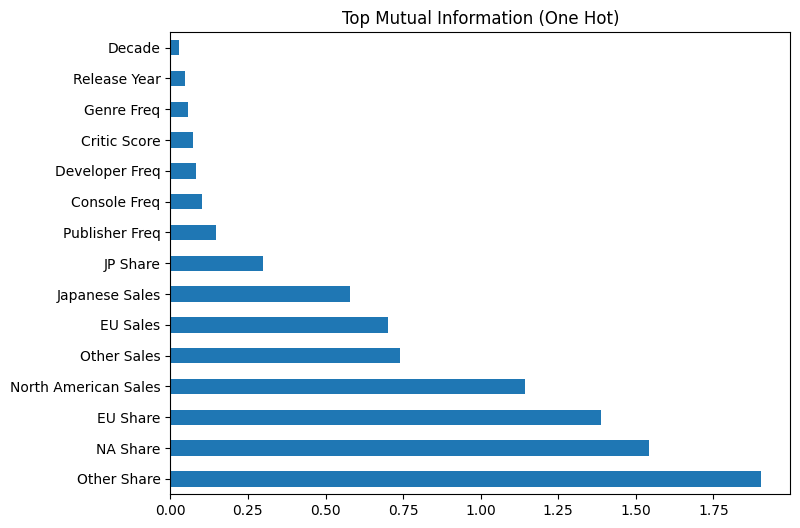

In [14]:
# Mutual Information

mi = mutual_info_regression(X_vt.fillna(0), y)
mi_scores = pd.Series(mi, index=X_vt.columns).sort_values(ascending=False)

print("Top MI features:\n", mi_scores.head(15))

mi_scores.head(15).plot(kind="barh", figsize=(8,6), title="Top Mutual Information (One Hot)")
plt.show()

Top RF features:
 EU Sales                0.493765
North American Sales    0.365103
Other Sales             0.109572
Japanese Sales          0.014195
NA Share                0.006660
EU Share                0.003865
Other Share             0.001869
JP Share                0.001226
Genre Freq              0.000883
Critic Score            0.000816
Release Year            0.000719
Developer Freq          0.000467
Console Freq            0.000332
Publisher Freq          0.000290
Is Recent               0.000150
dtype: float64


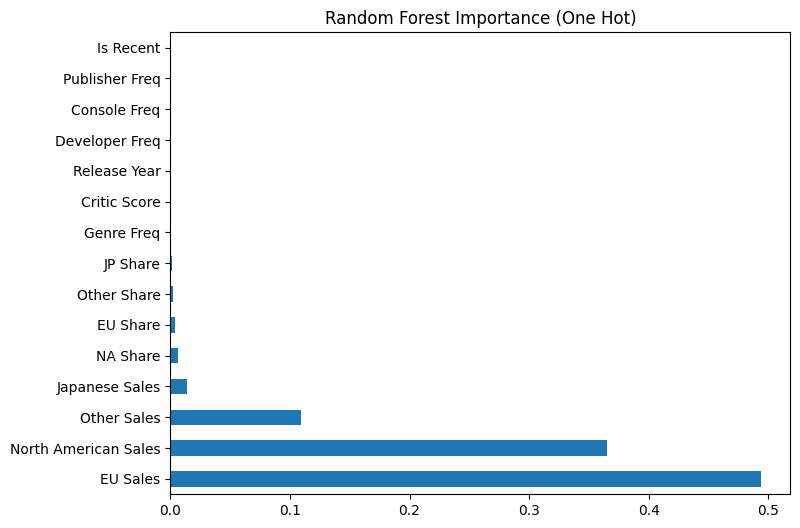

In [15]:
# Random Forest Importance

X_train, X_test, y_train, y_test = train_test_split(X_vt.fillna(0), y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X_vt.columns).sort_values(ascending=False)

print("Top RF features:\n", rf_importances.head(15))

rf_importances.head(15).plot(kind="barh", figsize=(8,6), title="Random Forest Importance (One Hot)")
plt.show()

In [16]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/5. Feature Selection/Feature Selection(Frequency).csv", index=False)